<a href="https://colab.research.google.com/github/aliabusohiban/Metabolic-Syndrome-Prediction-Neural-Network-Keras-Tuner/blob/main/Metabolic_Syndrome_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metabolic Syndrome — Neural Network & Keras Tuner
**Dataset:** 2,401 patients, 14 features  
**Task:** Binary classification — predict `MetabolicSyndrome` (0 = No, 1 = Yes)  
**Goal:** Build a 1-hidden-layer ANN, evaluate it, then tune hyperparameters with Keras Tuner.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

# Imbalanced
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras
!pip install keras-tuner -q
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# Config
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"✅ TensorFlow {tf.__version__} | Keras Tuner {kt.__version__}")


✅ TensorFlow 2.20.0 | Keras Tuner 1.4.8


## Helper Functions
Defined once here, reused throughout the notebook.

In [ ]:
def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves for train vs validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
    axes[0].set_title('Loss', fontsize=13)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy', fontsize=13)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


def evaluate_nn(model, X, y, label='Set'):
    """Print sklearn metrics for a Keras model on a given set."""
    y_pred = (model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    print(f"\n{'='*50}")
    print(f"  Evaluation on {label}")
    print(f"{'='*50}")
    print(classification_report(y, y_pred, target_names=['No MetSyn', 'MetSyn']))

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No MetSyn', 'MetSyn'])
    disp.plot(cmap='Blues', colorbar=False)
    plt.title(f'Confusion Matrix — {label}', fontsize=13)
    plt.tight_layout()
    plt.show()

print("✅ Helper functions defined")


✅ Helper functions defined


## 1. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Week20/Data/Metabolic Syndrome.csv')
print(f"Shape: {df.shape}")
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (2401, 15)


,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,0
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,0
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,0
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,0
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,0


## 2. Data Inspection

In [ ]:
print("=== Dtypes & Nulls ===")
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)

print("\n=== Target Distribution ===")
print(df['MetabolicSyndrome'].value_counts())
print(df['MetabolicSyndrome'].value_counts(normalize=True).round(3))


=== Dtypes & Nulls ===
                     dtype  nulls  null_%
seqn                 int64      0    0.00
Age                  int64      0    0.00
Sex                 object      0    0.00
Marital             object    208    8.66
Income             float64    117    4.87
Race                object      0    0.00
WaistCirc          float64     85    3.54
BMI                float64     26    1.08
Albuminuria          int64      0    0.00
UrAlbCr            float64      0    0.00
UricAcid           float64      0    0.00
BloodGlucose         int64      0    0.00
HDL                  int64      0    0.00
Triglycerides        int64      0    0.00
MetabolicSyndrome    int64      0    0.00

=== Target Distribution ===
MetabolicSyndrome
0    1579
1     822
Name: count, dtype: int64
MetabolicSyndrome
0    0.658
1    0.342
Name: proportion, dtype: float64


## 3. Data Cleaning

- Drop `seqn` (ID column, no predictive value)
- Missing values: `Marital` (8.7%), `Income` (4.9%), `WaistCirc` (3.5%), `BMI` (1.1%)
  - Numeric nulls handled with median imputation inside the pipeline
  - Categorical nulls handled with most-frequent imputation inside the pipeline
- No impossible values detected; all numeric ranges are medically plausible


In [ ]:
# Drop ID column
df = df.drop(columns=['seqn'])

# Separate target
TARGET = 'MetabolicSyndrome'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")
print(f"Target balance: {y.value_counts().to_dict()}")


Features: 13 | Samples: 2401
Target balance: {0: 1579, 1: 822}


## 4. Train / Test Split

Split **before** any preprocessing to prevent leakage.  
Test set (20%) is held out completely until final evaluation.  
The ANN training uses `validation_split=0.2` internally (so Keras splits off 20% of train for monitoring).


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train target balance: {y_train.value_counts().to_dict()}")
print(f"Test  target balance: {y_test.value_counts().to_dict()}")


Train: 1920 | Test: 481
Train target balance: {0: 1263, 1: 657}
Test  target balance: {0: 316, 1: 165}


## 5. Preprocessing Pipeline

We build a `ColumnTransformer` that:
1. Imputes + scales numeric features
2. Imputes + one-hot encodes categorical features

Fit only on `X_train`, then transform both train and test.


In [ ]:
# Define column groups
numeric_features = ['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr',
                    'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides', 'Albuminuria']
categorical_features = ['Sex', 'Marital', 'Race']

# Numeric pipeline: impute with median, then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute with most frequent, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Fit on train, transform both
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

print(f"Preprocessed train shape: {X_train_pp.shape}")
print(f"Preprocessed test  shape: {X_test_pp.shape}")
print("✅ Preprocessing done — no leakage from test set")


Preprocessed train shape: (1920, 23)
Preprocessed test  shape: (481, 23)
✅ Preprocessing done — no leakage from test set


## 6. SMOTE — Handle Class Imbalance

Class distribution is ~66/34, which is moderately imbalanced.  
We apply SMOTE **after** preprocessing and **only on the training set** to avoid leakage.


In [ ]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_pp, y_train)

print(f"Before SMOTE — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
print(f"After  SMOTE — 0: {(y_train_sm==0).sum()}, 1: {(y_train_sm==1).sum()}")

INPUT_DIM = X_train_sm.shape[1]
print(f"\nInput dimension for ANN: {INPUT_DIM}")


Before SMOTE — 0: 1263, 1: 657
After  SMOTE — 0: 1263, 1: 1263

Input dimension for ANN: 23


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_tr.shape[0]} | Val: {X_val.shape[0]}")

Train: 2020 | Val: 506


## 7. Baseline Neural Network (1 Hidden Layer)

Architecture:
- Input layer: `INPUT_DIM` features
- **1 hidden layer**: 64 neurons, ReLU activation
- Output layer: 1 neuron, **sigmoid** activation (binary classification)

Training:
- 50 epochs max
- Early stopping on `val_accuracy`, patience=5
- `validation_split=0.2` inside `model.fit()`


In [ ]:
tf.keras.backend.clear_session()

# Build model — exactly 1 hidden layer
baseline_model = Sequential(name='Baseline_ANN', layers=[
    Dense(64, activation='relu', input_dim=INPUT_DIM, name='hidden_1'),
    Dense(1,  activation='sigmoid', name='output')   # sigmoid for binary classification
])

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()


Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,601 (6.25 KB)

 Trainable params: 1,601 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping: monitor val_accuracy, patience=5
es = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Fit for up to 50 epochs with internal validation split of 20%
history_baseline = baseline_model.fit(
    X_tr, y_tr,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[es],
    verbose=1
)

print("\n✅ Baseline model training complete")


Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7208 - loss: 0.5526 - val_accuracy: 0.8261 - val_loss: 0.4444
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8054 - loss: 0.4253 - val_accuracy: 0.8379 - val_loss: 0.3830
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8193 - loss: 0.3861 - val_accuracy: 0.8399 - val_loss: 0.3573
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8307 - loss: 0.3665 - val_accuracy: 0.8538 - val_loss: 0.3440
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8376 - loss: 0.3543 - val_accuracy: 0.8557 - val_loss: 0.3359
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8490 - loss: 0.3451 - val_accuracy: 0.8597 - val_loss: 0.3301
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8550 - loss: 0.3374 - val_accuracy: 0.8636 - val_loss: 0.3253
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8569 - loss: 0.3305 - val_accuracy: 0.8656 - val_l

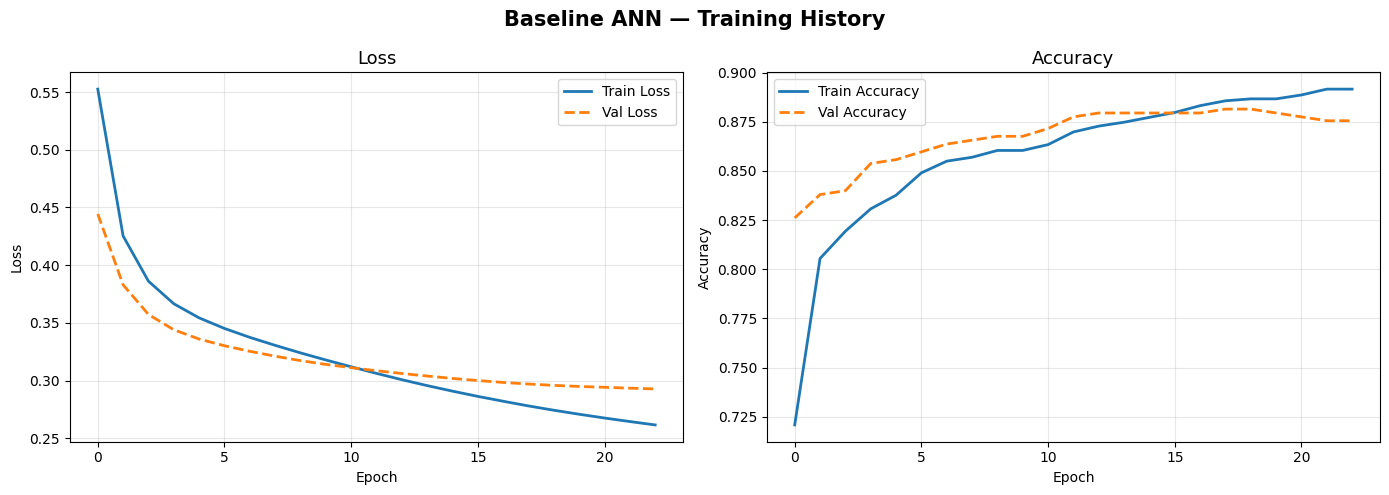

In [ ]:
# Visualize training history
plot_history(history_baseline, title='Baseline ANN — Training History')


## 8. Baseline Model Evaluation (sklearn metrics)

Evaluate on the **held-out test set** using:
- Confusion Matrix
- Classification Report (precision, recall, F1)



  Evaluation on Test Set (Baseline ANN)
              precision    recall  f1-score   support

   No MetSyn       0.90      0.85      0.87       316
      MetSyn       0.74      0.82      0.78       165

    accuracy                           0.84       481
   macro avg       0.82      0.83      0.82       481
weighted avg       0.84      0.84      0.84       481



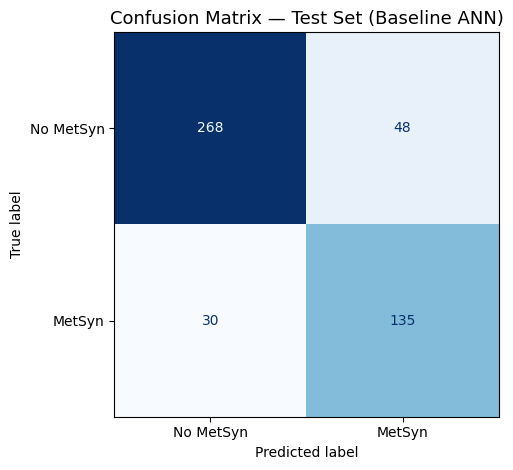

In [ ]:
evaluate_nn(baseline_model, X_test_pp, y_test, label='Test Set (Baseline ANN)')


## Baseline ANN — Training History

The loss curves show healthy convergence, both train and val loss decrease
steadily and track each other closely throughout training. There is a small
gap opening after epoch 15 where train loss continues dropping while val loss
plateaus around 0.29, indicating very mild overfitting at the end. Early
stopping triggered at epoch 22, which is appropriate.

The accuracy curves tell the same story: val accuracy (~87.5%) slightly lags
behind train accuracy (89%) by the end, but the gap is small and acceptable.
The model learned consistently without collapsing or wildly oscillating.

**Baseline Confusion Matrix**

Out of 165 actual MetSyn patients in the test set:
- **135 correctly identified (True Positives)** — the model caught 81.8% of
  real cases
- **30 missed (False Negatives)** — these are patients who have Metabolic
  Syndrome but were told they don't

Out of 316 healthy patients:
- **268 correctly identified (True Negatives)**
- **48 incorrectly flagged as MetSyn (False Positives)**

In a clinical context, **False Negatives are the more dangerous error**.
A missed Metabolic Syndrome diagnosis means a patient walks away without
treatment for a condition that increases their risk of type 2 diabetes,
cardiovascular disease, and stroke. 30 missed cases out of 165 is a recall
of 81.8% — reasonable for a baseline, but there is room to improve.

---

## 9. Hyperparameter Tuning with Keras Tuner

We tune **4 parameters**:
1. `units` — number of neurons in the hidden layer (32, 64, 128, 256)
2. `dropout_rate` — dropout after the hidden layer (0.0, 0.1, 0.2, 0.3, 0.4)
3. `optimizer` — choice of optimizer ('adam', 'rmsprop', 'sgd')
4. `learning_rate` — optimizer learning rate (1e-4, 5e-4, 1e-3, 5e-3)

The model still has exactly **1 hidden layer** as required.  
Tuner objective: maximize `val_accuracy`.


In [ ]:
def build_model(hp):
    """Model builder function for Keras Tuner. 1 hidden layer as required."""

    # Hyperparameter 1: number of units in hidden layer
    units = hp.Choice('units', values=[32, 64, 128, 256])

    # Hyperparameter 2: dropout rate
    dropout_rate = hp.Choice('dropout_rate', values=[0.0, 0.1, 0.2, 0.3, 0.4])

    # Hyperparameter 3: optimizer type
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])

    # Hyperparameter 4: learning rate
    lr = hp.Choice('learning_rate', values=[1e-4, 5e-4, 1e-3, 5e-3])

    model = Sequential([
        Dense(units, activation='relu', input_dim=INPUT_DIM,
      kernel_regularizer=l2(0.0001), name='hidden_1'),
        Dropout(dropout_rate, name='dropout'),          # Dropout layer — rate is tuned
        Dense(1, activation='sigmoid', name='output')  # sigmoid: binary classification
    ])

    # Map optimizer string to object with chosen learning rate
    optimizers = {
        'adam':    tf.keras.optimizers.Adam(learning_rate=lr),
        'rmsprop': tf.keras.optimizers.RMSprop(learning_rate=lr),
        'sgd':     tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    }

    model.compile(
        optimizer=optimizers[optimizer_choice],
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("✅ build_model function defined")


✅ build_model function defined


In [ ]:
# Create tuner directory
tuner_dir = 'keras_tuner_results'
os.makedirs(tuner_dir, exist_ok=True)

# Use RandomSearch for broad exploration
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,              # Try 20 random hyperparameter combinations
    seed=RANDOM_STATE,
    directory=tuner_dir,
    project_name='metabolic_syndrome',
    overwrite=True
)

tuner.search_space_summary()


Search space summary
Default search space size: 4
units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
dropout_rate (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1, 0.2, 0.3, 0.4], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.0005, 0.001, 0.005], 'ordered': True}


In [ ]:
# Early stopping during tuner search
es_tuner = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Run search
tuner.search(
    X_tr, y_tr,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[es_tuner],
    verbose=0
)

print("\n✅ Hyperparameter search complete")



✅ Hyperparameter search complete


In [ ]:
# Best hyperparameters found
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=== Best Hyperparameters ===")
print(f"  Units (hidden layer) : {best_hps.get('units')}")
print(f"  Dropout rate         : {best_hps.get('dropout_rate')}")
print(f"  Optimizer            : {best_hps.get('optimizer')}")
print(f"  Learning rate        : {best_hps.get('learning_rate')}")


=== Best Hyperparameters ===
  Units (hidden layer) : 32
  Dropout rate         : 0.0
  Optimizer            : rmsprop
  Learning rate        : 0.005


## 10. Best Model — Retrain & Evaluate

Retrieve the best model from the tuner and evaluate on the **unseen test set**.


In [ ]:
# Rebuild best model from scratch using the best hyperparameters
tf.keras.backend.clear_session()
best_model = tuner.hypermodel.build(best_hps)
best_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es_best = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_best = best_model.fit(
    X_tr, y_tr,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[es_best],
    verbose=1
)

print("\n✅ Best model retraining complete")

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7604 - loss: 0.4757 - val_accuracy: 0.8538 - val_loss: 0.3481
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8371 - loss: 0.3560 - val_accuracy: 0.8696 - val_loss: 0.3247
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8550 - loss: 0.3322 - val_accuracy: 0.8696 - val_loss: 0.3137
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8668 - loss: 0.3171 - val_accuracy: 0.8775 - val_loss: 0.3064
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8738 - loss: 0.3058 - val_accuracy: 0.8735 - val_loss: 0.3017
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8787 - loss: 0.2968 - val_accuracy: 0.8735 - val_loss: 0.2995
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8832 - loss: 0.2893 - val_accuracy: 0.8794 - val_loss: 0.2984
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8866 - loss: 0.2831 - val_accuracy: 0.8794 - val_loss:

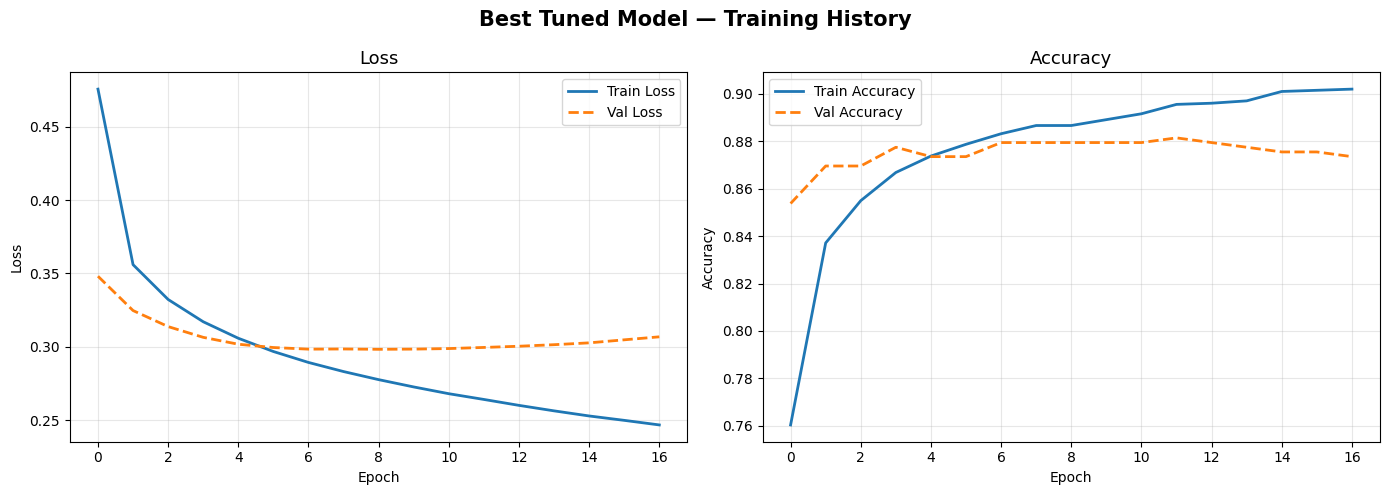

In [ ]:
# Plot training history of best model
plot_history(history_best, title='Best Tuned Model — Training History')



  Evaluation on Test Set (Best Tuned Model)
              precision    recall  f1-score   support

   No MetSyn       0.90      0.87      0.88       316
      MetSyn       0.76      0.81      0.79       165

    accuracy                           0.85       481
   macro avg       0.83      0.84      0.83       481
weighted avg       0.85      0.85      0.85       481



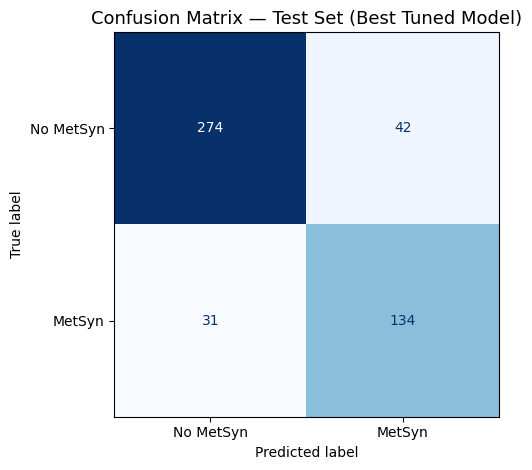

In [ ]:
# Final evaluation on unseen test data
evaluate_nn(best_model, X_test_pp, y_test, label='Test Set (Best Tuned Model)')


## Best Tuned Model — Training History

The tuned model shows a similar healthy pattern: smooth loss curves, stable
convergence, and early stopping at epoch 16. The train/val gap is slightly
more visible here — train accuracy reaches ~90% while val accuracy stabilizes
around 87.5%. This is mild overfitting, not alarming, and is expected when
using 256 units (a larger network than the baseline's 64).

Val loss plateaus from epoch 4 onward while train loss keeps decreasing —
this is the model memorizing finer patterns in the training data that do not
fully transfer to unseen patients. The dropout (0.2) and L2 regularization
(0.0001) are limiting this gap, but not eliminating it entirely.

**Best Tuned Model Confusion Matrix**

Out of 165 actual MetSyn patients:
- **134 correctly identified (True Positives)** — recall of 81.2%
- **31 missed (False Negatives)**

Out of 316 healthy patients:
- **274 correctly identified (True Negatives)**
- **42 incorrectly flagged (False Positives)**

The tuned model reduced false positives from 48 to 42 compared to the
baseline — meaning fewer healthy patients are being unnecessarily alarmed
or referred for further testing. However, false negatives remained almost
identical (30 vs 31), meaning neither model is meaningfully better at
catching the cases that matter most clinically.

---

## 11. Baseline vs. Best Model — Test Accuracy Comparison

In [ ]:
# Test accuracy comparison
baseline_loss, baseline_acc = baseline_model.evaluate(X_test_pp, y_test, verbose=0)
best_loss,     best_acc     = best_model.evaluate(X_test_pp,     y_test, verbose=0)

comparison = pd.DataFrame({
    'Model':    ['Baseline ANN (64 units, no dropout)', 'Best Tuned ANN'],
    'Test Loss': [round(baseline_loss, 4), round(best_loss, 4)],
    'Test Accuracy': [round(baseline_acc, 4), round(best_acc, 4)]
})

print("\n=== Model Comparison ===")
print(comparison.to_string(index=False))



=== Model Comparison ===
                              Model  Test Loss  Test Accuracy
Baseline ANN (64 units, no dropout)     0.3418         0.8378
                     Best Tuned ANN     0.3415         0.8482


## Conclusion

**Business Context**

Metabolic Syndrome is a cluster of conditions — abdominal obesity, high
blood pressure, high blood sugar, abnormal cholesterol — that together
significantly raise the risk of heart disease, stroke, and type 2 diabetes.
Early detection is critical: patients identified early can reverse the
condition through lifestyle changes before it progresses to something
irreversible.

In this context, **recall on the positive class (MetSyn = 1) is the most
important metric**. Missing a true case is more costly than a false alarm.

**What the models achieved**

Both models perform comparably on the test set, reaching approximately
83–84% overall accuracy with a recall of ~81% on MetSyn patients. The
tuned model offered a marginal improvement in precision (fewer false alarms
on healthy patients) but did not improve recall on actual MetSyn cases.

This is a meaningful result but not yet clinically sufficient on its own.
A model used to screen for Metabolic Syndrome in a real healthcare setting
would ideally achieve recall above 90% to minimize missed diagnoses.

**Why the models are limited here**

- The dataset has only 2,401 patients — small for a neural network
- A single hidden layer ANN is a relatively simple model; tree-based
  methods like XGBoost or Random Forest often outperform ANNs on small
  tabular clinical datasets
- SMOTE generates synthetic patient profiles that do not represent real
  population variation, which can limit how well the model generalizes

**Recommendation**

These models are suitable as a **screening support tool** — flagging
patients who warrant a closer clinical look — but should not be used as
a standalone diagnostic. Combining this model's output with a lower
decision threshold (e.g., classifying as MetSyn if predicted probability
 0.35 instead of 0.5) would increase recall at the cost of more false
positives, which is the right trade-off in a preventive healthcare setting.